In [10]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Click "Choose Files" → select AAPL.csv

df = pd.read_csv('AAPL.csv')
print("Loaded!", df.shape)
df.head()

Saving AAPL.csv to AAPL (1).csv
Loaded! (10409, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)
df = df[df.index >= '2018-01-01']

print("Ready! Shape:", df.shape)
df.head()

Ready! Shape: (1065, 6)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-01-02,42.540001,43.075001,42.314999,43.064999,41.135754,102223600
2018-01-03,43.132500,43.637501,42.990002,43.057499,41.128586,118071600
2018-01-04,43.134998,43.367500,43.020000,43.257500,41.319633,89738400
2018-01-05,43.360001,43.842499,43.262501,43.750000,41.790070,94640000
2018-01-08,43.587502,43.902500,43.482498,43.587502,41.634850,82271200


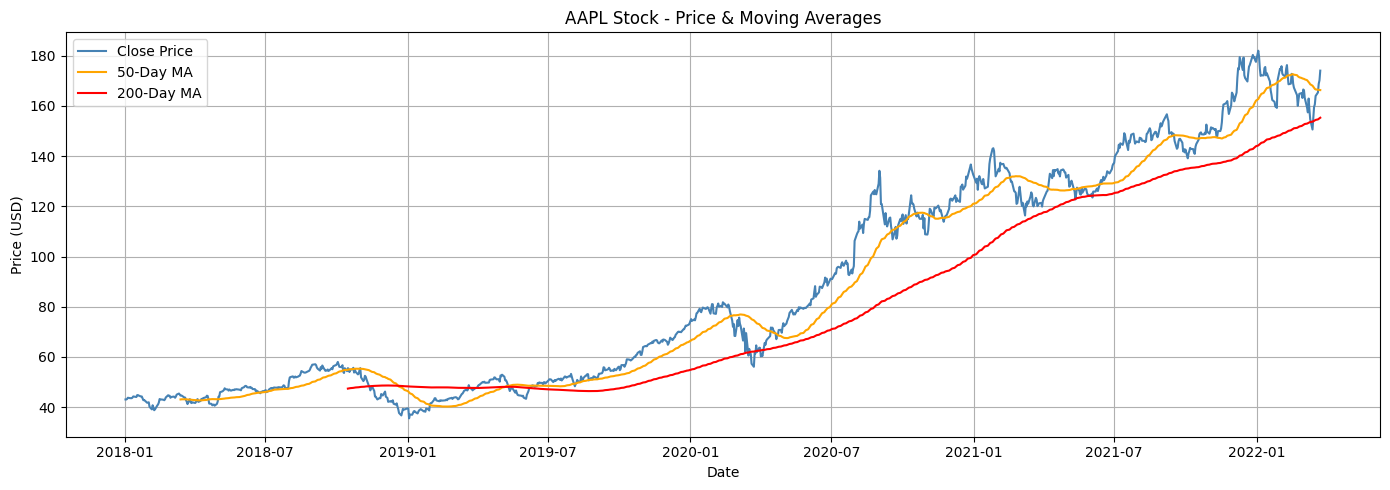

In [12]:
import matplotlib.pyplot as plt

df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['Close'], label='Close Price', color='steelblue')
plt.plot(df['MA_50'], label='50-Day MA', color='orange')
plt.plot(df['MA_200'], label='200-Day MA', color='red')
plt.title('AAPL Stock - Price & Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('stock_analysis.png')
plt.show()

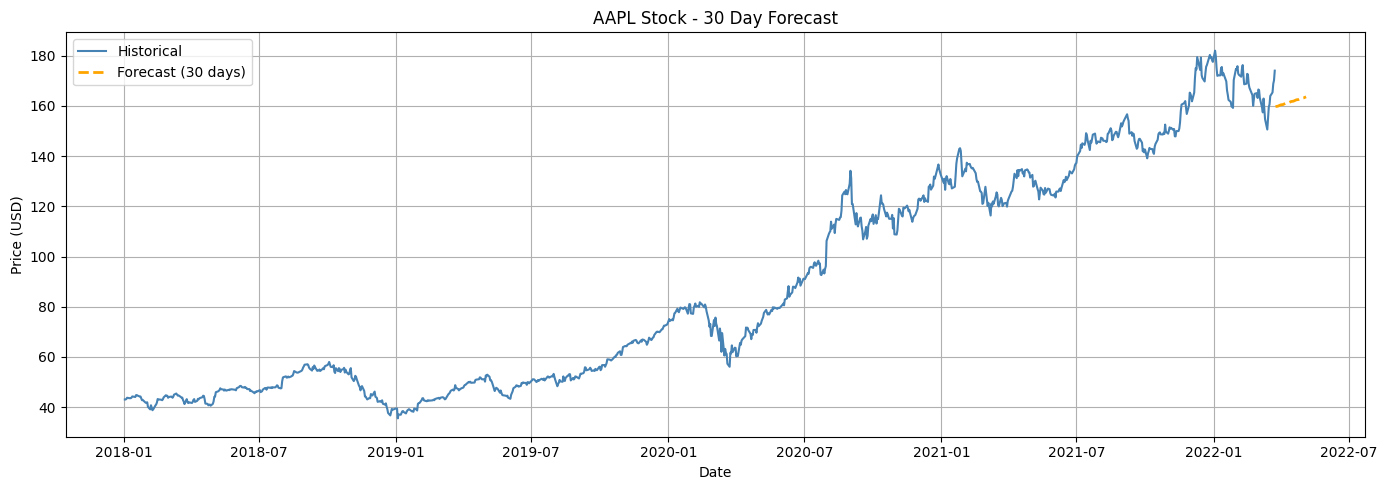

In [13]:
import numpy as np
from sklearn.linear_model import LinearRegression

data = df[['Close']].dropna().copy()
data['Days'] = np.arange(len(data))

model = LinearRegression()
model.fit(data[['Days']], data['Close'])

future_days = np.arange(len(data), len(data)+30).reshape(-1,1)
future_prices = model.predict(future_days)
future_dates = pd.date_range(start=data.index[-1], periods=31, freq='B')[1:]

plt.figure(figsize=(14, 5))
plt.plot(data.index, data['Close'], label='Historical', color='steelblue')
plt.plot(future_dates, future_prices, label='Forecast (30 days)',
         color='orange', linestyle='--', linewidth=2)
plt.title('AAPL Stock - 30 Day Forecast')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('forecast.png')
plt.show()

In [15]:
print("=" * 40)
print("   STOCK PRICE FORECASTING - SUMMARY")
print("=" * 40)
print(f"Stock       : AAPL (Apple Inc.)")
print(f"Records     : {len(data)}")
print(f"Start Price : ${round(data['Close'].iloc[0], 2)}")
print(f"End Price   : ${round(data['Close'].iloc[-1], 2)}")
print(f"Model       : Linear Regression")
print(f"Forecast    : Next 30 Days")
print("=" * 40)
print("Project by: Aashritha | Finance Student")

   STOCK PRICE FORECASTING - SUMMARY
Stock       : AAPL (Apple Inc.)
Records     : 1065
Start Price : $43.06
End Price   : $174.07
Model       : Linear Regression
Forecast    : Next 30 Days
Project by: Aashritha | Finance Student
